In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("lead_data.csv")
df.head()

,Name,Company,Industry,Region,Company Size,Traffic Source,Site Visits,Session Duration,Emails Opened,Demo Requested,Days Since First Interaction,Converted
0,Laura Williams,"Thornton, Young and Davenport",Education,East,Small,Email,37,9.22,18,0,174,1
1,Sergio Hartman,Braun PLC,IT,South,Small,Webinar,7,20.58,7,0,182,0
2,Aaron Taylor,"Matthews, Weaver and Zavala",Healthcare,North,Medium,Ads,28,15.48,14,1,364,1
3,Tara Jones,Wright LLC,Finance,West,Large,Ads,7,19.43,19,1,216,0
4,Jamie Conley,"Daugherty, Ramsey and Lindsey",Education,North,Medium,Email,3,14.52,20,0,207,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Name                          30000 non-null  object 
 1   Company                       30000 non-null  object 
 2   Industry                      30000 non-null  object 
 3   Region                        30000 non-null  object 
 4   Company Size                  30000 non-null  object 
 5   Traffic Source                30000 non-null  object 
 6   Site Visits                   30000 non-null  int64  
 7   Session Duration              30000 non-null  float64
 8   Emails Opened                 30000 non-null  int64  
 9   Demo Requested                30000 non-null  int64  
 10  Days Since First Interaction  30000 non-null  int64  
 11  Converted                     30000 non-null  int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB


In [4]:
df.describe()

,Site Visits,Session Duration,Emails Opened,Demo Requested,Days Since First Interaction,Converted
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,25.491433,15.513745,9.977200,0.499300,182.634067,0.640633
std,14.400902,8.386764,6.059492,0.500008,106.040343,0.479823
min,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,13.000000,8.190000,5.000000,0.000000,90.000000,0.000000
50%,25.000000,15.520000,10.000000,0.000000,182.000000,1.000000
75%,38.000000,22.820000,15.000000,1.000000,275.000000,1.000000
max,50.000000,30.000000,20.000000,1.000000,366.000000,1.000000


In [5]:
df.isnull().sum()

Name                            0
Company                         0
Industry                        0
Region                          0
Company Size                    0
Traffic Source                  0
Site Visits                     0
Session Duration                0
Emails Opened                   0
Demo Requested                  0
Days Since First Interaction    0
Converted                       0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.drop_duplicates(inplace=True)

# Outliers

In [8]:
for col in ['Emails Opened', 'Site Visits', 'Session Duration']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)


In [9]:
for col in ['Emails Opened', 'Site Visits', 'Session Duration']:
    
    print(f"\n🔹 Column: {col}")
    print("Before:")
    print(df[col].describe())
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = np.clip(df[col], lower, upper)
    
    print("After:")
    print(df[col].describe())


🔹 Column: Emails Opened
Before:
count    30000.000000
mean         9.977200
std          6.059492
min          0.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         20.000000
Name: Emails Opened, dtype: float64
After:
count    30000.000000
mean         9.977200
std          6.059492
min          0.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         20.000000
Name: Emails Opened, dtype: float64

🔹 Column: Site Visits
Before:
count    30000.000000
mean        25.491433
std         14.400902
min          1.000000
25%         13.000000
50%         25.000000
75%         38.000000
max         50.000000
Name: Site Visits, dtype: float64
After:
count    30000.000000
mean        25.491433
std         14.400902
min          1.000000
25%         13.000000
50%         25.000000
75%         38.000000
max         50.000000
Name: Site Visits, dtype: float64

🔹 Column: Session Duration
Before:
count    30000.000000
mean        15.51374

In [10]:
for col in ['Emails Opened', 'Site Visits', 'Session Duration']:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Show values outside range
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"\nOutliers in {col}:")
    print(outliers[col])


Outliers in Emails Opened:
Series([], Name: Emails Opened, dtype: int64)

Outliers in Site Visits:
Series([], Name: Site Visits, dtype: int64)

Outliers in Session Duration:
Series([], Name: Session Duration, dtype: float64)


# column Created

In [11]:
df['Engagement Score'] = (
    df['Emails Opened'] +
    df['Site Visits'] +
    df['Session Duration'])

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Engagement Score'] = scaler.fit_transform(df[['Engagement Score']])
print(df['Engagement Score'].head())


0    0.632598
1    0.325670
2    0.562804
3    0.438024
4    0.356115
Name: Engagement Score, dtype: float64


In [13]:
# Calculate conversion rate per source
source_score = df.groupby('Traffic Source')['Converted'].mean()

print(source_score)

Traffic Source
Ads        0.641592
Email      0.644778
Organic    0.634098
Webinar    0.642108
Name: Converted, dtype: float64


In [17]:
df['Source Impact Score'] = df['Traffic Source'].map(source_score)


In [19]:
print(df[['Traffic Source', 'Source Impact Score']].head())

  Traffic Source  Source Impact Score
0          Email             0.644778
1        Webinar             0.642108
2            Ads             0.641592
3            Ads             0.641592
4          Email             0.644778


In [18]:
print(df.columns)

Index(['Name', 'Company', 'Industry', 'Region', 'Company Size',
       'Traffic Source', 'Site Visits', 'Session Duration', 'Emails Opened',
       'Demo Requested', 'Days Since First Interaction', 'Converted',
       'Engagement Score', 'Source Impact Score'],
      dtype='object')


## Visulazation

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns


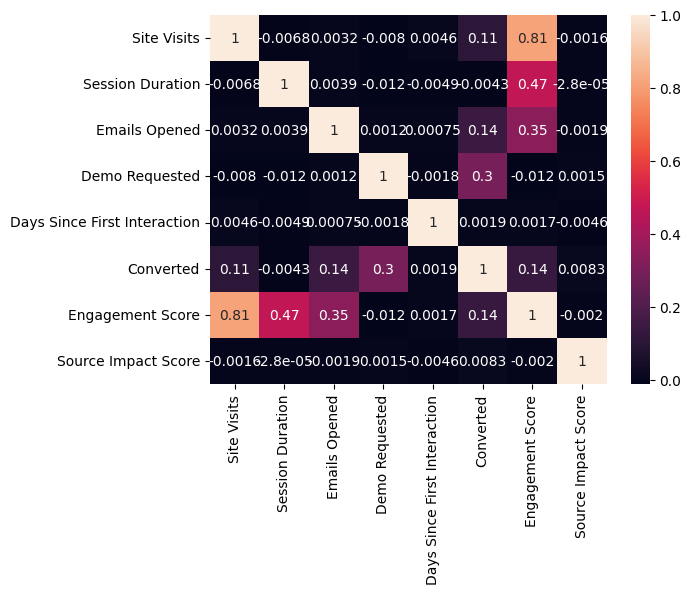

In [21]:
# Correlation
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


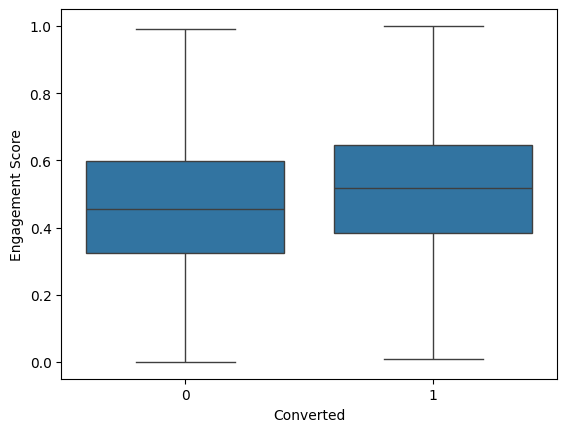

In [22]:
sns.boxplot(x='Converted', y='Engagement Score', data=df)
plt.show()


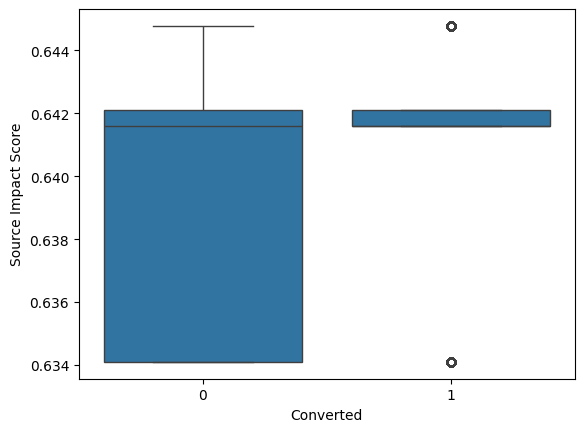

In [23]:
sns.boxplot(x='Converted', y='Source Impact Score', data=df)
plt.show()

In [26]:
df.to_csv("processed_lead_data.csv", index=False)